# Normal toy example using SBI

In [1]:
import torch
import numpy as np
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
from sbi.utils.torchutils import BoxUniform
from scipy.stats import norm, uniform
from sbi.analysis import plot_summary
import matplotlib.pyplot as plt
import seaborn as sns


torch_device = "cpu"
torch.set_default_device(torch_device)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Model

**Prior:**
-  $\mu \sim \text{Uniform}[0, 10]$
-  $n \sim \text{Discrete Uniform}[10, 200]$

**Simulator:**
-  $x_{1:n} \sim N(\mu, 1)$
-  $s_1 = (\overline{x}, n)$
-  $s_2 = (\overline{x}, \overline{x^2}, n)$

In [5]:
prior_torch = BoxUniform(
    low=torch.tensor([0.0, 10.0], device=torch_device),
    high=torch.tensor([10.0, 200.0], device=torch_device),
    device=torch_device
)

In [3]:
def simulator_torch_1(theta):
    x = torch.randn(theta[1].int(), device=torch_device) + theta[0]
    s1 = torch.tensor([torch.mean(x), theta[1]], device=torch_device)
    return s1

In [4]:
def simulator_torch_2(theta):
    x = torch.randn(theta[1].int(), device=torch_device) + theta[0]
    s2 = torch.tensor([torch.mean(x), torch.mean(x**2), theta[1]], device=torch_device)
    return s2

## NPE-C

In [7]:
simulation_budget = 50000
seed = 1
prior = prior_torch
num_epochs=500
num_posterior_samples=1000

In [ ]:
simulator = simulator_torch_2

prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulator = process_simulator(simulator, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)

learning_rate = 0.0005  # default value

torch.manual_seed(seed)
np.random.seed(seed)

theta, x = simulate_for_sbi(
    simulator=simulator, proposal=prior, num_simulations=simulation_budget
)

100%|██████████| 50000/50000 [00:02<00:00, 19066.01it/s]


In [11]:
x_1 = x[:, [0, 2]]
x_2 = x
x_1, x_2

(tensor([[1.6835e-01, 2.1846e+01],
         [2.2213e+00, 1.2969e+02],
         [8.4909e+00, 1.1891e+02],
         ...,
         [4.0948e+00, 1.0975e+02],
         [5.1318e+00, 1.0424e+02],
         [4.9051e+00, 1.7177e+02]]),
 tensor([[1.6835e-01, 9.7783e-01, 2.1846e+01],
         [2.2213e+00, 5.9477e+00, 1.2969e+02],
         [8.4909e+00, 7.3189e+01, 1.1891e+02],
         ...,
         [4.0948e+00, 1.7745e+01, 1.0975e+02],
         [5.1318e+00, 2.7433e+01, 1.0424e+02],
         [4.9051e+00, 2.4892e+01, 1.7177e+02]]))

**Simulator 1**

 Training neural network. Epochs trained: 111

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\normal_toy\sbi-logs\NPE_C\2026-03-17T13_32_35.526941' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


 Neural network successfully converged after 112 epochs.

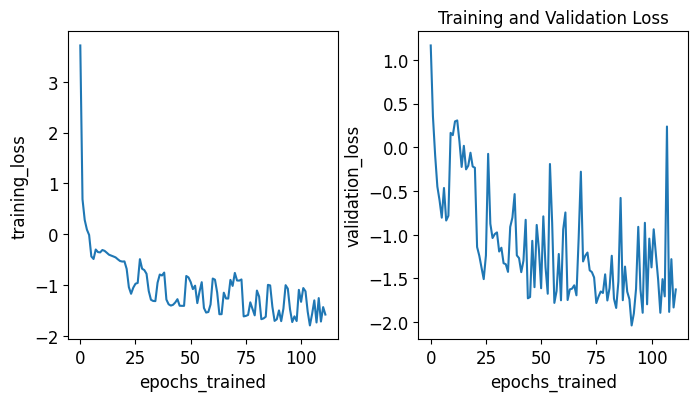

In [ ]:
torch.manual_seed(seed)
np.random.seed(seed)

inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)

density_estimator = inference.append_simulations(theta, x_1).train(
    max_num_epochs=num_epochs, 
    learning_rate=learning_rate,
    stop_after_epochs=20
)

fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

In [13]:
posterior_1 = inference.build_posterior(density_estimator)

**Simulator 2**

 Training neural network. Epochs trained: 135

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\normal_toy\sbi-logs\NPE_C\2026-03-17T13_50_59.600465' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


 Neural network successfully converged after 136 epochs.

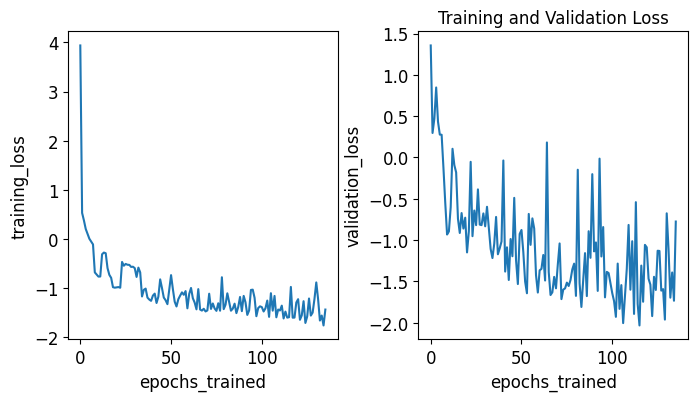

In [17]:
torch.manual_seed(seed)
np.random.seed(seed)

inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)

density_estimator = inference.append_simulations(theta, x_2).train(
    max_num_epochs=num_epochs, 
    learning_rate=learning_rate,
    stop_after_epochs=20
)

fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

In [18]:
posterior_2 = inference.build_posterior(density_estimator)

If the true values are:
-  $\mu = 6.0$,
-  $n = 75$.

The observed summary statistics are shown below as

In [59]:
torch.manual_seed(1)
np.random.seed(1)
true_theta = torch.tensor([6.0, 75.0], device=torch_device)
x_o_2 = simulator_torch_2(true_theta)
x_o_1 = x_o_2[[0, 2]]
true_theta, x_o_1, x_o_2

(tensor([ 6., 75.]),
 tensor([ 5.9354, 75.0000]),
 tensor([ 5.9354, 36.0564, 75.0000]))

Plug in observed data to get the posterior.

In [54]:
theta_trained1 = posterior_1.set_default_x(x_o_1).sample((num_posterior_samples,), x=x_o_1)
theta_trained1 = theta_trained1.reshape((num_posterior_samples, 2))
theta_trained1_numpy = theta_trained1.cpu().numpy()

theta_trained2 = posterior_2.set_default_x(x_o_2).sample((num_posterior_samples,), x=x_o_2)
theta_trained2 = theta_trained2.reshape((num_posterior_samples, 2))
theta_trained2_numpy = theta_trained2.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 58989.96it/s]


**True posterior by the truncated normal distribution**

In [55]:
prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)
x_o_1_numpy = x_o_1.cpu().numpy()

prior = uniform.pdf(theta_grid, loc=prior_a, scale=(prior_b - prior_a))

likelihood = norm.pdf(x_o_1_numpy[0], loc=theta_grid, scale=1/np.sqrt(x_o_1_numpy[1]))

unnormalized_posterior = likelihood * prior
d_theta = theta_grid[1] - theta_grid[0]
posterior = unnormalized_posterior / (np.sum(unnormalized_posterior) * d_theta)

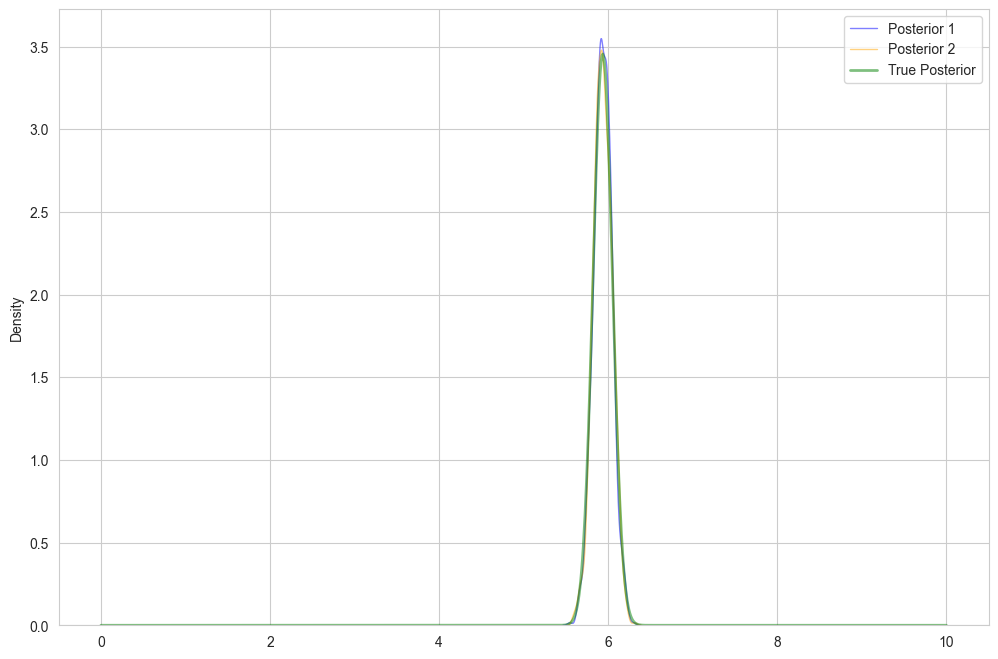

In [56]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained1_numpy[:, 0], label='Posterior 1', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained2_numpy[:, 0], label='Posterior 2', color='orange', linewidth=1, alpha=0.5)
plt.plot(theta_grid, posterior, label='True Posterior', color='green', linewidth=2, alpha=0.5)
plt.legend()
plt.show()

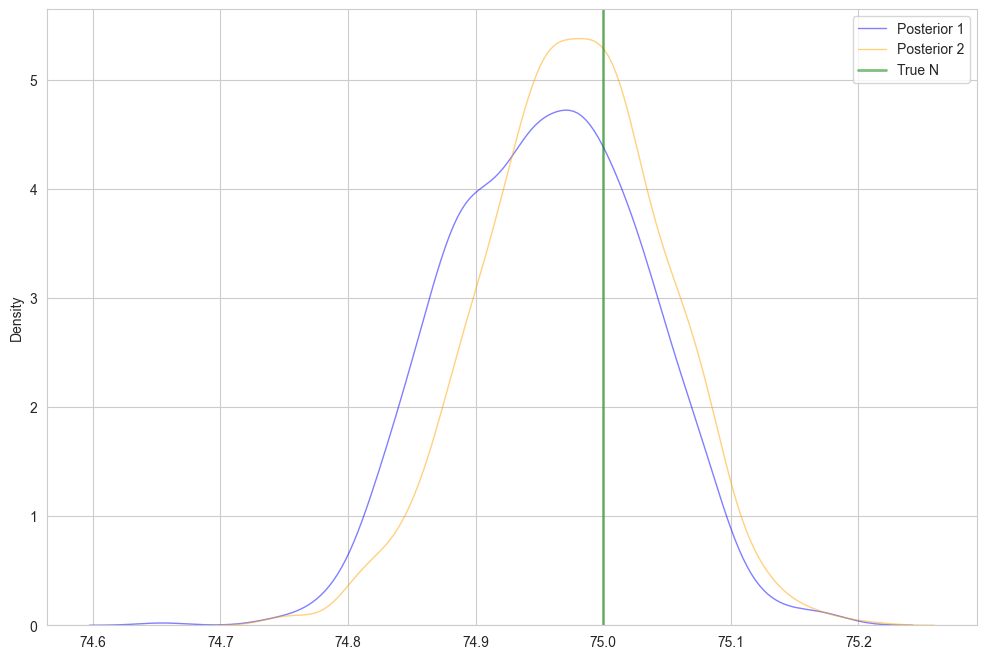

In [57]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained1_numpy[:, 1], label='Posterior 1', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained2_numpy[:, 1], label='Posterior 2', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=true_theta[1], label='True N', color='green', linewidth=2, alpha=0.5)
plt.legend()
plt.show()

### Posterior distribution of $\mu$ that changes by $n$.

In [62]:
n_list = [25.0, 100.0, 150.0]

prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)
x_o_1_numpy = x_o_1.cpu().numpy()

prior = uniform.pdf(theta_grid, loc=prior_a, scale=(prior_b - prior_a))

true_posterior_list = []
npe_posterior_list = []
for i in range(len(n_list)):
    x_o_1_numpy[1] = n_list[i]
    x_o_1[1] = n_list[i]

    likelihood = norm.pdf(x_o_1_numpy[0], loc=theta_grid, scale=1/np.sqrt(x_o_1_numpy[1]))
    unnormalized_posterior = likelihood * prior
    d_theta = theta_grid[1] - theta_grid[0]
    posterior = unnormalized_posterior / (np.sum(unnormalized_posterior) * d_theta)
    true_posterior_list.append(posterior)

    theta_trained1 = posterior_1.set_default_x(x_o_1).sample((num_posterior_samples,), x=x_o_1)
    theta_trained1 = theta_trained1.reshape((num_posterior_samples, 2))
    theta_trained1_numpy = theta_trained1.cpu().numpy()
    npe_posterior_list.append(theta_trained1_numpy)

100%|██████████| 1000/1000 [00:00<00:00, 25016.87it/s]
1099it [00:00, 27026.55it/s]            


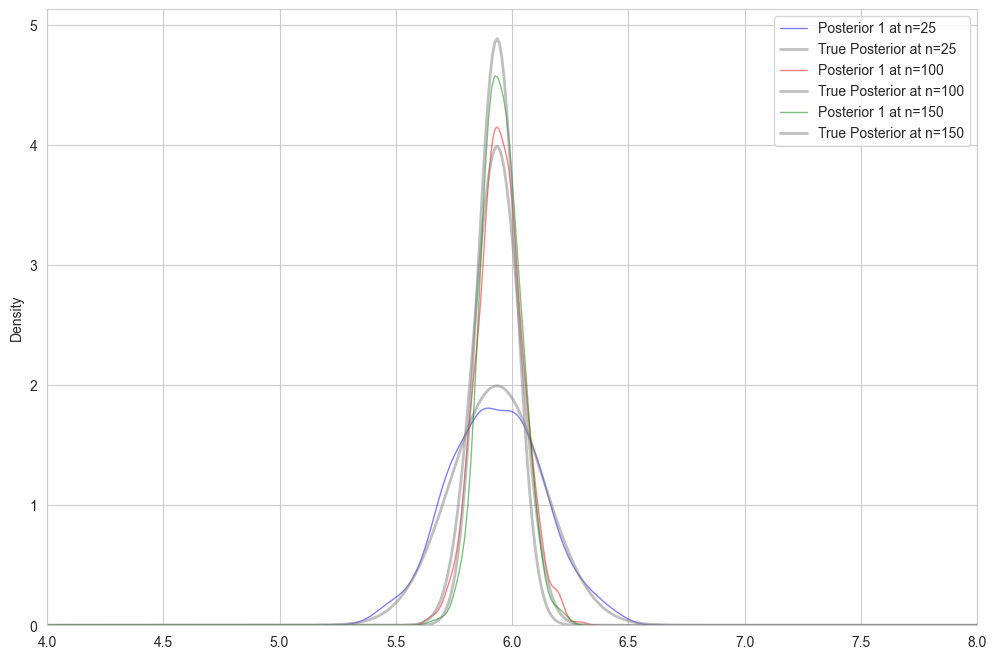

In [65]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(npe_posterior_list[0][:, 0], label='Posterior 1 at n=25', color='blue', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[0], label='True Posterior at n=25', color='gray', linewidth=2, alpha=0.5)
sns.kdeplot(npe_posterior_list[1][:, 0], label='Posterior 1 at n=100', color='red', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[1], label='True Posterior at n=100', color='gray', linewidth=2, alpha=0.5)
sns.kdeplot(npe_posterior_list[2][:, 0], label='Posterior 1 at n=150', color='green', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[2], label='True Posterior at n=150', color='gray', linewidth=2, alpha=0.5)
plt.xlim(4, 8)
plt.legend()
plt.show()

In [66]:
n_list = [25.0, 100.0, 150.0]

prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)

prior = uniform.pdf(theta_grid, loc=prior_a, scale=(prior_b - prior_a))

true_posterior_list = []
npe_posterior_list = []
for i in range(len(n_list)):
    true_theta = torch.tensor([6.0, n_list[i]], device=torch_device)
    x_o_2 = simulator_torch_2(true_theta)
    x_o_2_numpy = x_o_2.cpu().numpy()

    likelihood = norm.pdf(x_o_2_numpy[0], loc=theta_grid, scale=1/np.sqrt(x_o_2_numpy[2]))
    unnormalized_posterior = likelihood * prior
    d_theta = theta_grid[1] - theta_grid[0]
    posterior = unnormalized_posterior / (np.sum(unnormalized_posterior) * d_theta)
    true_posterior_list.append(posterior)

    theta_trained2 = posterior_2.set_default_x(x_o_2).sample((num_posterior_samples,), x=x_o_2)
    theta_trained2 = theta_trained2.reshape((num_posterior_samples, 2))
    theta_trained2_numpy = theta_trained2.cpu().numpy()
    npe_posterior_list.append(theta_trained2_numpy)

100%|██████████| 1000/1000 [00:00<00:00, 25766.70it/s]


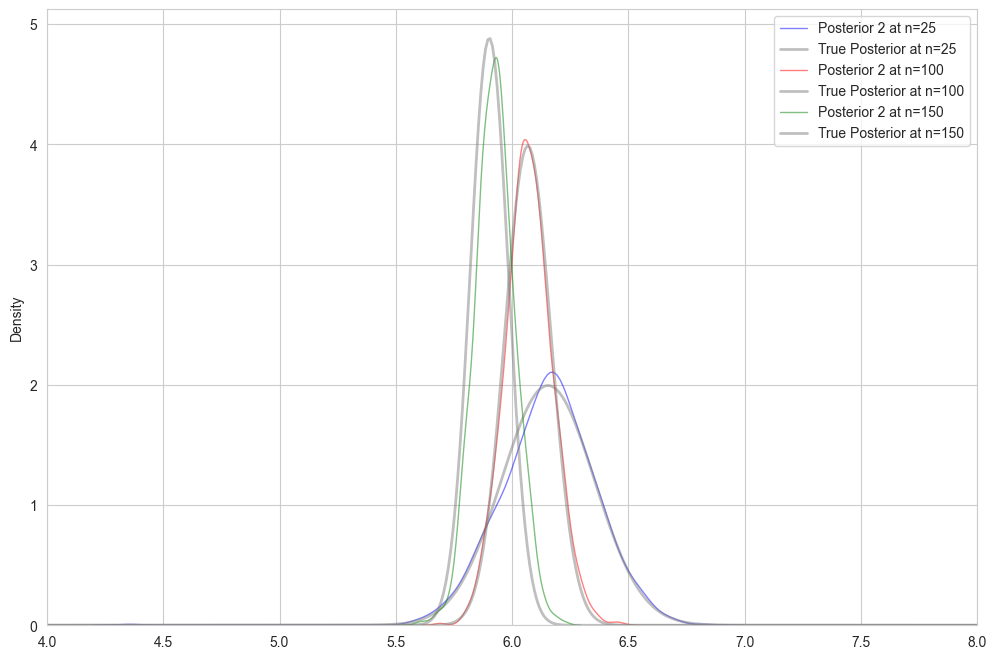

In [67]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(npe_posterior_list[0][:, 0], label='Posterior 2 at n=25', color='blue', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[0], label='True Posterior at n=25', color='gray', linewidth=2, alpha=0.5)
sns.kdeplot(npe_posterior_list[1][:, 0], label='Posterior 2 at n=100', color='red', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[1], label='True Posterior at n=100', color='gray', linewidth=2, alpha=0.5)
sns.kdeplot(npe_posterior_list[2][:, 0], label='Posterior 2 at n=150', color='green', linewidth=1, alpha=0.5)
plt.plot(theta_grid, true_posterior_list[2], label='True Posterior at n=150', color='gray', linewidth=2, alpha=0.5)
plt.xlim(4, 8)
plt.legend()
plt.show()

### 2D summary statistics using $1/\sqrt{n}$

In [68]:
def simulator_torch_3(theta):
    x = torch.randn(theta[1].int(), device=torch_device) + theta[0]
    s3 = torch.tensor([torch.mean(x), 1/torch.sqrt(theta[1])], device=torch_device)
    return s3

In [72]:
x_1 = x[:, [0, 2]]
x_2 = x
x_3 = x[:, [0, 2]]
x_3[:, 1] = 1/torch.sqrt(x_3[:, 1])
x_1, x_2, x_3

(tensor([[1.6835e-01, 2.1846e+01],
         [2.2213e+00, 1.2969e+02],
         [8.4909e+00, 1.1891e+02],
         ...,
         [4.0948e+00, 1.0975e+02],
         [5.1318e+00, 1.0424e+02],
         [4.9051e+00, 1.7177e+02]]),
 tensor([[1.6835e-01, 9.7783e-01, 2.1846e+01],
         [2.2213e+00, 5.9477e+00, 1.2969e+02],
         [8.4909e+00, 7.3189e+01, 1.1891e+02],
         ...,
         [4.0948e+00, 1.7745e+01, 1.0975e+02],
         [5.1318e+00, 2.7433e+01, 1.0424e+02],
         [4.9051e+00, 2.4892e+01, 1.7177e+02]]),
 tensor([[0.1684, 0.2140],
         [2.2213, 0.0878],
         [8.4909, 0.0917],
         ...,
         [4.0948, 0.0955],
         [5.1318, 0.0979],
         [4.9051, 0.0763]]))

In [77]:
prior = prior_torch

In [78]:
torch.manual_seed(seed)
np.random.seed(seed)

inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)

density_estimator = inference.append_simulations(theta, x_3).train(
    max_num_epochs=num_epochs, 
    learning_rate=learning_rate,
    stop_after_epochs=20
)

fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

 Training neural network. Epochs trained: 2

  0%|          | 0/1000 [37:37<?, ?it/s]


 Training neural network. Epochs trained: 48

KeyboardInterrupt: 

In [ ]:
posterior_3 = inference.build_posterior(density_estimator)